In [ ]:
!pip install google-adk -q
!pip install litellm -q
!pip install pandas numpy scipy matplotlib seaborn -q
!pip install openpyxl -q

print("✅ All packages installed!")

import os
import io
import json
import getpass
import asyncio
from datetime import datetime
from typing import Optional, Dict, Any, List

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from google.adk.agents import Agent
from google.adk.models.lite_llm import LiteLlm
from google.adk.sessions import InMemorySessionService
from google.adk.runners import Runner
from google.adk.tools.tool_context import ToolContext
from google.genai import types

import warnings
warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Libraries loaded!")

def make_serializable(obj):
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_serializable(item) for item in obj]
    elif isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.bool_,)):
        return bool(obj)
    elif isinstance(obj, pd.Timestamp):
        return obj.isoformat()
    elif pd.isna(obj):
        return None
    else:
        return obj

print("✅ Serialization helper ready!")

print("=" * 60)
print("  🔐 API KEY CONFIGURATION")
print("=" * 60)

try:
    from google.colab import userdata
    api_key = userdata.get('OPENAI_API_KEY')
    print("✅ API key loaded from Colab Secrets!")
except:
    print("\n📝 Enter your OpenAI API key (hidden input):")
    api_key = getpass.getpass("OpenAI API Key: ")

os.environ['OPENAI_API_KEY'] = api_key

if api_key and len(api_key) > 20:
    print(f"✅ API Key configured: {api_key[:8]}...{api_key[-4:]}")
else:
    print("❌ Invalid API key!")

MODEL = "openai/gpt-4o-mini"
print(f"✅ Using model: {MODEL}")

class DataStore:
    _instance = None

    def __new__(cls):
        if cls._instance is None:
            cls._instance = super().__new__(cls)
            cls._instance.datasets = {}
            cls._instance.analysis_history = []
        return cls._instance

    def add_dataset(self, name: str, df: pd.DataFrame, source: str = "unknown"):
        self.datasets[name] = {
            "data": df,
            "loaded_at": datetime.now().isoformat(),
            "source": source,
            "shape": (int(df.shape[0]), int(df.shape[1])),
            "columns": list(df.columns)
        }
        return f"Dataset '{name}' stored: {df.shape[0]} rows × {df.shape[1]} columns"

    def get_dataset(self, name: str) -> Optional[pd.DataFrame]:
        if name in self.datasets:
            return self.datasets[name]["data"]
        return None

    def list_datasets(self) -> List[str]:
        return list(self.datasets.keys())

    def log_analysis(self, analysis_type: str, dataset: str, result_summary: str):
        self.analysis_history.append({
            "timestamp": datetime.now().isoformat(),
            "type": analysis_type,
            "dataset": dataset,
            "summary": result_summary
        })

DATA_STORE = DataStore()
print("✅ DataStore initialized!")

In [ ]:
def load_csv(file_path: str, dataset_name: str, tool_context: ToolContext) -> dict:
    print(f"📂 Loading CSV: {file_path} as '{dataset_name}'")

    try:
        df = pd.read_csv(file_path)
        result = DATA_STORE.add_dataset(dataset_name, df, source=file_path)

        datasets = tool_context.state.get("loaded_datasets", [])
        if dataset_name not in datasets:
            datasets.append(dataset_name)
        tool_context.state["loaded_datasets"] = datasets
        tool_context.state["active_dataset"] = dataset_name

        summary = {
            "status": "success",
            "message": result,
            "preview": {
                "columns": list(df.columns),
                "shape": [int(df.shape[0]), int(df.shape[1])],
                "dtypes": {k: str(v) for k, v in df.dtypes.items()},
                "sample": make_serializable(df.head(3).to_dict(orient="records"))
            }
        }
        return make_serializable(summary)

    except Exception as e:
        return {"status": "error", "message": f"Failed to load CSV: {str(e)}"}


def create_sample_dataset(dataset_type: str, dataset_name: str, tool_context: ToolContext) -> dict:
    print(f"📂 Creating sample dataset: {dataset_type} as '{dataset_name}'")

    np.random.seed(42)

    if dataset_type == "sales":
        n = 500
        dates = pd.date_range("2023-01-01", periods=n, freq="D")
        df = pd.DataFrame({
            "order_id": range(1000, 1000 + n),
            "date": dates[:n].astype(str),
            "product": np.random.choice(["Laptop", "Phone", "Tablet", "Watch", "Headphones"], n),
            "category": np.random.choice(["Electronics", "Accessories"], n, p=[0.6, 0.4]),
            "region": np.random.choice(["North", "South", "East", "West"], n),
            "quantity": np.random.randint(1, 10, n),
            "unit_price": np.random.uniform(50, 1500, n).round(2),
            "discount": np.random.choice([0.0, 0.05, 0.10, 0.15, 0.20], n),
            "customer_type": np.random.choice(["New", "Returning", "VIP"], n, p=[0.3, 0.5, 0.2])
        })
        df["revenue"] = (df["quantity"] * df["unit_price"] * (1 - df["discount"])).round(2)
        df["profit_margin"] = np.random.uniform(0.15, 0.45, n).round(3)
        df["profit"] = (df["revenue"] * df["profit_margin"]).round(2)

    elif dataset_type == "customers":
        n = 300
        df = pd.DataFrame({
            "customer_id": range(5000, 5000 + n),
            "age": np.random.randint(18, 75, n),
            "gender": np.random.choice(["M", "F", "Other"], n, p=[0.48, 0.48, 0.04]),
            "income": np.random.lognormal(10.5, 0.5, n).round(0),
            "education": np.random.choice(["High School", "Bachelor", "Master", "PhD"], n, p=[0.25, 0.45, 0.22, 0.08]),
            "membership_years": np.random.exponential(3, n).round(1),
            "total_purchases": np.random.randint(1, 100, n),
            "avg_order_value": np.random.uniform(25, 500, n).round(2),
            "satisfaction_score": np.clip(np.random.normal(7.5, 1.5, n), 1, 10).round(1),
            "churn_risk": np.random.choice(["Low", "Medium", "High"], n, p=[0.6, 0.3, 0.1])
        })
        df["lifetime_value"] = (df["total_purchases"] * df["avg_order_value"]).round(2)

    elif dataset_type == "timeseries":
        dates = pd.date_range("2022-01-01", "2024-01-01", freq="D")
        n = len(dates)
        trend = np.linspace(100, 200, n)
        seasonal = 30 * np.sin(np.linspace(0, 6 * np.pi, n))
        noise = np.random.normal(0, 10, n)

        df = pd.DataFrame({
            "date": dates.astype(str),
            "value": (trend + seasonal + noise).round(2),
            "volume": np.random.randint(1000, 10000, n),
            "category": np.random.choice(["A", "B", "C"], n)
        })

    elif dataset_type == "survey":
        n = 200
        df = pd.DataFrame({
            "respondent_id": range(1, n + 1),
            "age_group": np.random.choice(["18-24", "25-34", "35-44", "45-54", "55+"], n),
            "q1_satisfaction": np.random.randint(1, 6, n),
            "q2_likelihood_recommend": np.random.randint(0, 11, n),
            "q3_ease_of_use": np.random.randint(1, 6, n),
            "q4_value_for_money": np.random.randint(1, 6, n),
            "q5_support_quality": np.random.randint(1, 6, n),
            "response_time_mins": np.random.exponential(10, n).round(1)
        })
    else:
        return {"status": "error", "message": f"Unknown dataset type: {dataset_type}. Use: sales, customers, timeseries, survey"}

    result = DATA_STORE.add_dataset(dataset_name, df, source=f"sample_{dataset_type}")

    datasets = tool_context.state.get("loaded_datasets", [])
    if dataset_name not in datasets:
        datasets.append(dataset_name)
    tool_context.state["loaded_datasets"] = datasets
    tool_context.state["active_dataset"] = dataset_name

    return make_serializable({
        "status": "success",
        "message": result,
        "description": f"Created sample {dataset_type} dataset",
        "columns": list(df.columns),
        "shape": [int(df.shape[0]), int(df.shape[1])],
        "sample": df.head(3).to_dict(orient="records")
    })


def list_available_datasets(tool_context: ToolContext) -> dict:
    print("📋 Listing datasets")

    datasets = DATA_STORE.list_datasets()

    if not datasets:
        return {"status": "info", "message": "No datasets loaded. Use create_sample_dataset or load_csv."}

    info = {}
    for name in datasets:
        ds = DATA_STORE.datasets[name]
        info[name] = {
            "rows": int(ds["shape"][0]),
            "columns": int(ds["shape"][1]),
            "column_names": ds["columns"]
        }

    return make_serializable({
        "status": "success",
        "datasets": info,
        "active_dataset": tool_context.state.get("active_dataset")
    })


print("✅ Data loading tools defined!")

In [ ]:
def describe_dataset(dataset_name: str, tool_context: ToolContext) -> dict:
    print(f"📊 Describing dataset: {dataset_name}")

    df = DATA_STORE.get_dataset(dataset_name)
    if df is None:
        return {"status": "error", "message": f"Dataset '{dataset_name}' not found"}

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    result = {
        "status": "success",
        "dataset": dataset_name,
        "overview": {
            "total_rows": int(len(df)),
            "total_columns": int(len(df.columns)),
            "numeric_columns": numeric_cols,
            "categorical_columns": categorical_cols,
            "memory_mb": round(float(df.memory_usage(deep=True).sum() / 1024 / 1024), 2),
            "duplicate_rows": int(df.duplicated().sum()),
            "missing_total": int(df.isnull().sum().sum())
        }
    }

    if numeric_cols:
        stats_dict = {}
        for col in numeric_cols:
            col_data = df[col].dropna()
            if len(col_data) > 0:
                stats_dict[col] = {
                    "count": int(len(col_data)),
                    "mean": round(float(col_data.mean()), 3),
                    "std": round(float(col_data.std()), 3),
                    "min": round(float(col_data.min()), 3),
                    "25%": round(float(col_data.quantile(0.25)), 3),
                    "50%": round(float(col_data.median()), 3),
                    "75%": round(float(col_data.quantile(0.75)), 3),
                    "max": round(float(col_data.max()), 3),
                    "skewness": round(float(col_data.skew()), 3),
                    "missing": int(df[col].isnull().sum())
                }
        result["numeric_summary"] = stats_dict

    if categorical_cols:
        cat_dict = {}
        for col in categorical_cols[:10]:
            vc = df[col].value_counts()
            cat_dict[col] = {
                "unique_values": int(df[col].nunique()),
                "top_values": {str(k): int(v) for k, v in vc.head(5).items()},
                "missing": int(df[col].isnull().sum())
            }
        result["categorical_summary"] = cat_dict

    DATA_STORE.log_analysis("describe", dataset_name, "Statistics generated")
    return make_serializable(result)


def correlation_analysis(dataset_name: str, method: str = "pearson", tool_context: ToolContext = None) -> dict:
    print(f"📊 Correlation analysis: {dataset_name} ({method})")

    df = DATA_STORE.get_dataset(dataset_name)
    if df is None:
        return {"status": "error", "message": f"Dataset '{dataset_name}' not found"}

    numeric_df = df.select_dtypes(include=[np.number])

    if numeric_df.shape[1] < 2:
        return {"status": "error", "message": "Need at least 2 numeric columns"}

    corr_matrix = numeric_df.corr(method=method)

    strong_corrs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]
            val = corr_matrix.iloc[i, j]
            if abs(val) > 0.5:
                strong_corrs.append({
                    "var1": col1,
                    "var2": col2,
                    "correlation": round(float(val), 3),
                    "strength": "strong" if abs(val) > 0.7 else "moderate"
                })

    strong_corrs.sort(key=lambda x: abs(x["correlation"]), reverse=True)

    corr_dict = {}
    for col in corr_matrix.columns:
        corr_dict[col] = {k: round(float(v), 3) for k, v in corr_matrix[col].items()}

    DATA_STORE.log_analysis("correlation", dataset_name, f"{method} correlation")

    return make_serializable({
        "status": "success",
        "method": method,
        "correlation_matrix": corr_dict,
        "strong_correlations": strong_corrs[:10],
        "insight": f"Found {len(strong_corrs)} pairs with |correlation| > 0.5"
    })


def hypothesis_test(dataset_name: str, test_type: str, column1: str,
                   column2: str = None, group_column: str = None,
                   tool_context: ToolContext = None) -> dict:
    print(f"📊 Hypothesis test: {test_type} on {dataset_name}")

    df = DATA_STORE.get_dataset(dataset_name)
    if df is None:
        return {"status": "error", "message": f"Dataset '{dataset_name}' not found"}

    if column1 not in df.columns:
        return {"status": "error", "message": f"Column '{column1}' not found"}

    try:
        if test_type == "normality":
            data = df[column1].dropna()
            if len(data) > 5000:
                data = data.sample(5000)
            stat, p = stats.shapiro(data)

            return make_serializable({
                "status": "success",
                "test": "Shapiro-Wilk Normality Test",
                "column": column1,
                "statistic": round(float(stat), 4),
                "p_value": round(float(p), 6),
                "is_normal": bool(p > 0.05),
                "interpretation": "Data appears normally distributed" if p > 0.05 else "Data is NOT normally distributed"
            })

        elif test_type == "ttest":
            if group_column is None:
                return {"status": "error", "message": "group_column required for t-test"}

            groups = df[group_column].dropna().unique()
            if len(groups) != 2:
                return {"status": "error", "message": f"T-test needs exactly 2 groups, found {len(groups)}: {list(groups)}"}

            g1 = df[df[group_column] == groups[0]][column1].dropna()
            g2 = df[df[group_column] == groups[1]][column1].dropna()

            stat, p = stats.ttest_ind(g1, g2)

            return make_serializable({
                "status": "success",
                "test": "Independent Samples T-Test",
                "comparing": column1,
                "group1": {"name": str(groups[0]), "mean": round(float(g1.mean()), 3), "n": int(len(g1))},
                "group2": {"name": str(groups[1]), "mean": round(float(g2.mean()), 3), "n": int(len(g2))},
                "t_statistic": round(float(stat), 4),
                "p_value": round(float(p), 6),
                "significant": bool(p < 0.05),
                "interpretation": "Significant difference" if p < 0.05 else "No significant difference"
            })

        elif test_type == "anova":
            if group_column is None:
                return {"status": "error", "message": "group_column required for ANOVA"}

            groups_data = [grp[column1].dropna().values for _, grp in df.groupby(group_column)]
            group_names = list(df[group_column].unique())

            stat, p = stats.f_oneway(*groups_data)

            group_stats = []
            for name in group_names:
                grp_data = df[df[group_column] == name][column1].dropna()
                group_stats.append({
                    "group": str(name),
                    "mean": round(float(grp_data.mean()), 3),
                    "std": round(float(grp_data.std()), 3),
                    "n": int(len(grp_data))
                })

            return make_serializable({
                "status": "success",
                "test": "One-Way ANOVA",
                "comparing": column1,
                "across": group_column,
                "n_groups": int(len(group_names)),
                "group_statistics": group_stats,
                "f_statistic": round(float(stat), 4),
                "p_value": round(float(p), 6),
                "significant": bool(p < 0.05),
                "interpretation": "Significant differences among groups" if p < 0.05 else "No significant differences"
            })

        elif test_type == "chi2":
            if column2 is None:
                return {"status": "error", "message": "column2 required for chi-square test"}

            contingency = pd.crosstab(df[column1], df[column2])
            chi2, p, dof, _ = stats.chi2_contingency(contingency)

            return make_serializable({
                "status": "success",
                "test": "Chi-Square Test of Independence",
                "variables": [column1, column2],
                "chi2_statistic": round(float(chi2), 4),
                "p_value": round(float(p), 6),
                "degrees_of_freedom": int(dof),
                "significant": bool(p < 0.05),
                "interpretation": "Variables are dependent" if p < 0.05 else "Variables are independent"
            })

        else:
            return {"status": "error", "message": f"Unknown test: {test_type}. Use: normality, ttest, anova, chi2"}

    except Exception as e:
        return {"status": "error", "message": f"Test failed: {str(e)}"}


def outlier_detection(dataset_name: str, column: str, method: str = "iqr",
                      tool_context: ToolContext = None) -> dict:
    print(f"📊 Outlier detection: {column} in {dataset_name}")

    df = DATA_STORE.get_dataset(dataset_name)
    if df is None:
        return {"status": "error", "message": f"Dataset '{dataset_name}' not found"}

    if column not in df.columns:
        return {"status": "error", "message": f"Column '{column}' not found"}

    data = df[column].dropna()

    if method == "iqr":
        Q1 = float(data.quantile(0.25))
        Q3 = float(data.quantile(0.75))
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = data[(data < lower) | (data > upper)]

        return make_serializable({
            "status": "success",
            "method": "IQR (Interquartile Range)",
            "column": column,
            "bounds": {"lower": round(lower, 3), "upper": round(upper, 3)},
            "iqr": round(IQR, 3),
            "total_values": int(len(data)),
            "outlier_count": int(len(outliers)),
            "outlier_pct": round(float(len(outliers) / len(data) * 100), 2),
            "outlier_examples": [round(float(x), 2) for x in outliers.head(10).tolist()]
        })

    elif method == "zscore":
        z = np.abs(stats.zscore(data))
        outliers = data[z > 3]

        return make_serializable({
            "status": "success",
            "method": "Z-Score (threshold: 3)",
            "column": column,
            "total_values": int(len(data)),
            "outlier_count": int(len(outliers)),
            "outlier_pct": round(float(len(outliers) / len(data) * 100), 2),
            "outlier_examples": [round(float(x), 2) for x in outliers.head(10).tolist()]
        })

    return {"status": "error", "message": f"Unknown method: {method}. Use: iqr, zscore"}


print("✅ Statistical analysis tools defined!")

In [ ]:
def create_visualization(dataset_name: str, chart_type: str, x_column: str,
                         y_column: str = None, color_column: str = None,
                         title: str = None, tool_context: ToolContext = None) -> dict:
    print(f"📈 Creating {chart_type}: {x_column}" + (f" vs {y_column}" if y_column else ""))

    df = DATA_STORE.get_dataset(dataset_name)
    if df is None:
        return {"status": "error", "message": f"Dataset '{dataset_name}' not found"}

    if x_column not in df.columns:
        return {"status": "error", "message": f"Column '{x_column}' not found"}

    try:
        fig, ax = plt.subplots(figsize=(10, 6))
        chart_title = title or f"{chart_type.title()}: {x_column}" + (f" vs {y_column}" if y_column else "")

        if chart_type == "histogram":
            if color_column and color_column in df.columns:
                for grp in df[color_column].unique():
                    subset = df[df[color_column] == grp][x_column].dropna()
                    ax.hist(subset, alpha=0.6, label=str(grp), bins=30)
                ax.legend()
            else:
                ax.hist(df[x_column].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
            ax.set_xlabel(x_column)
            ax.set_ylabel("Frequency")

        elif chart_type == "scatter":
            if not y_column:
                return {"status": "error", "message": "y_column required for scatter"}
            if color_column and color_column in df.columns:
                for grp in df[color_column].unique():
                    subset = df[df[color_column] == grp]
                    ax.scatter(subset[x_column], subset[y_column], alpha=0.6, label=str(grp), s=50)
                ax.legend()
            else:
                ax.scatter(df[x_column], df[y_column], alpha=0.6, s=50, color='steelblue')
            ax.set_xlabel(x_column)
            ax.set_ylabel(y_column)

        elif chart_type == "bar":
            if y_column:
                data = df.groupby(x_column)[y_column].sum().sort_values(ascending=False)
            else:
                data = df[x_column].value_counts()

            colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(data)))
            bars = ax.bar(range(len(data)), data.values, color=colors)
            ax.set_xticks(range(len(data)))
            ax.set_xticklabels([str(x) for x in data.index], rotation=45, ha='right')
            ax.set_xlabel(x_column)
            ax.set_ylabel(y_column if y_column else "Count")

            for bar, val in zip(bars, data.values):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * max(data.values),
                       f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

        elif chart_type == "line":
            if not y_column:
                return {"status": "error", "message": "y_column required for line"}
            df_sorted = df.sort_values(x_column)
            if color_column and color_column in df.columns:
                for grp in df_sorted[color_column].unique():
                    subset = df_sorted[df_sorted[color_column] == grp]
                    ax.plot(subset[x_column], subset[y_column], label=str(grp), marker='o', markersize=3)
                ax.legend()
            else:
                ax.plot(df_sorted[x_column], df_sorted[y_column], marker='o', markersize=3, color='steelblue')
            ax.set_xlabel(x_column)
            ax.set_ylabel(y_column)
            plt.xticks(rotation=45)

        elif chart_type == "box":
            if color_column and color_column in df.columns:
                groups = df[color_column].unique()
                data_groups = [df[df[color_column] == g][x_column].dropna() for g in groups]
                bp = ax.boxplot(data_groups, labels=[str(g) for g in groups], patch_artist=True)
                colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(groups)))
                for patch, color in zip(bp['boxes'], colors):
                    patch.set_facecolor(color)
                ax.set_xlabel(color_column)
            else:
                bp = ax.boxplot(df[x_column].dropna(), patch_artist=True)
                bp['boxes'][0].set_facecolor('steelblue')
            ax.set_ylabel(x_column)

        elif chart_type == "heatmap":
            numeric_df = df.select_dtypes(include=[np.number])
            corr = numeric_df.corr()
            im = ax.imshow(corr, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
            ax.set_xticks(range(len(corr.columns)))
            ax.set_yticks(range(len(corr.columns)))
            ax.set_xticklabels(corr.columns, rotation=45, ha='right')
            ax.set_yticklabels(corr.columns)

            for i in range(len(corr)):
                for j in range(len(corr)):
                    val = corr.iloc[i, j]
                    color = 'white' if abs(val) > 0.5 else 'black'
                    ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=8)

            plt.colorbar(im, ax=ax, label='Correlation')

        elif chart_type == "pie":
            data = df[x_column].value_counts()
            colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(data)))
            wedges, texts, autotexts = ax.pie(data.values, labels=data.index, autopct='%1.1f%%',
                                               colors=colors, startangle=90)
            ax.axis('equal')

        else:
            return {"status": "error", "message": f"Unknown chart: {chart_type}. Use: histogram, scatter, bar, line, box, heatmap, pie"}

        ax.set_title(chart_title, fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
        plt.close()

        return make_serializable({
            "status": "success",
            "chart_type": chart_type,
            "title": chart_title,
            "message": "Chart displayed successfully"
        })

    except Exception as e:
        plt.close()
        return {"status": "error", "message": f"Visualization failed: {str(e)}"}


def create_distribution_report(dataset_name: str, column: str, tool_context: ToolContext = None) -> dict:
    print(f"📈 Distribution report: {column} in {dataset_name}")

    df = DATA_STORE.get_dataset(dataset_name)
    if df is None:
        return {"status": "error", "message": f"Dataset '{dataset_name}' not found"}

    if column not in df.columns:
        return {"status": "error", "message": f"Column '{column}' not found"}

    data = df[column].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Distribution Analysis: {column}', fontsize=14, fontweight='bold')

    axes[0, 0].hist(data, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    data.plot.kde(ax=axes[0, 0], color='red', linewidth=2)
    axes[0, 0].set_title('Histogram with KDE')
    axes[0, 0].set_xlabel(column)
    axes[0, 0].set_ylabel('Density')

    bp = axes[0, 1].boxplot(data, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    axes[0, 1].set_title('Box Plot')
    axes[0, 1].set_ylabel(column)

    stats.probplot(data, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('Q-Q Plot (Normality)')

    vp = axes[1, 1].violinplot(data, vert=True, showmeans=True, showmedians=True)
    vp['bodies'][0].set_facecolor('steelblue')
    axes[1, 1].set_title('Violin Plot')
    axes[1, 1].set_ylabel(column)

    plt.tight_layout()
    plt.show()
    plt.close()

    skew_val = float(data.skew())
    shape = "approximately symmetric" if abs(skew_val) < 0.5 else ("right-skewed" if skew_val > 0 else "left-skewed")

    return make_serializable({
        "status": "success",
        "column": column,
        "statistics": {
            "count": int(len(data)),
            "mean": round(float(data.mean()), 3),
            "median": round(float(data.median()), 3),
            "std": round(float(data.std()), 3),
            "skewness": round(skew_val, 3),
            "kurtosis": round(float(data.kurtosis()), 3),
            "min": round(float(data.min()), 3),
            "max": round(float(data.max()), 3)
        },
        "distribution_shape": shape,
        "message": "4 distribution plots displayed"
    })


print("✅ Visualization tools defined!")

In [ ]:
def filter_data(dataset_name: str, condition: str, new_dataset_name: str, tool_context: ToolContext) -> dict:
    print(f"🔄 Filtering {dataset_name}: {condition}")

    df = DATA_STORE.get_dataset(dataset_name)
    if df is None:
        return {"status": "error", "message": f"Dataset '{dataset_name}' not found"}

    try:
        filtered = df.query(condition)
        DATA_STORE.add_dataset(new_dataset_name, filtered, source=f"filtered:{dataset_name}")

        datasets = tool_context.state.get("loaded_datasets", [])
        if new_dataset_name not in datasets:
            datasets.append(new_dataset_name)
        tool_context.state["loaded_datasets"] = datasets

        return make_serializable({
            "status": "success",
            "original_rows": int(len(df)),
            "filtered_rows": int(len(filtered)),
            "rows_removed": int(len(df) - len(filtered)),
            "new_dataset": new_dataset_name
        })
    except Exception as e:
        return {"status": "error", "message": f"Filter failed: {str(e)}"}


def aggregate_data(dataset_name: str, group_by: str, aggregations: str,
                   new_dataset_name: str, tool_context: ToolContext) -> dict:
    print(f"🔄 Aggregating {dataset_name} by {group_by}")

    df = DATA_STORE.get_dataset(dataset_name)
    if df is None:
        return {"status": "error", "message": f"Dataset '{dataset_name}' not found"}

    try:
        group_cols = [c.strip() for c in group_by.split(",")]

        agg_dict = {}
        for agg in aggregations.split(","):
            col, func = agg.strip().split(":")
            agg_dict[col.strip()] = func.strip()

        result_df = df.groupby(group_cols).agg(agg_dict).reset_index()

        new_cols = list(group_cols) + [f"{col}_{func}" for col, func in agg_dict.items()]
        result_df.columns = new_cols

        DATA_STORE.add_dataset(new_dataset_name, result_df, source=f"aggregated:{dataset_name}")

        datasets = tool_context.state.get("loaded_datasets", [])
        if new_dataset_name not in datasets:
            datasets.append(new_dataset_name)
        tool_context.state["loaded_datasets"] = datasets

        return make_serializable({
            "status": "success",
            "grouped_by": group_cols,
            "aggregations": agg_dict,
            "result_rows": int(len(result_df)),
            "columns": list(result_df.columns),
            "new_dataset": new_dataset_name,
            "preview": result_df.head(5).to_dict(orient="records")
        })
    except Exception as e:
        return {"status": "error", "message": f"Aggregation failed: {str(e)}"}


def add_calculated_column(dataset_name: str, new_column: str, expression: str,
                          tool_context: ToolContext) -> dict:
    print(f"🔄 Adding column '{new_column}' to {dataset_name}")

    df = DATA_STORE.get_dataset(dataset_name)
    if df is None:
        return {"status": "error", "message": f"Dataset '{dataset_name}' not found"}

    try:
        df_copy = df.copy()
        df_copy[new_column] = df_copy.eval(expression)

        DATA_STORE.datasets[dataset_name]["data"] = df_copy
        DATA_STORE.datasets[dataset_name]["columns"] = list(df_copy.columns)

        sample_vals = df_copy[new_column].head(5)

        return make_serializable({
            "status": "success",
            "new_column": new_column,
            "expression": expression,
            "sample_values": [round(float(x), 3) if pd.notna(x) else None for x in sample_vals]
        })
    except Exception as e:
        return {"status": "error", "message": f"Calculation failed: {str(e)}"}


print("✅ Transformation tools defined!")

def generate_summary_report(dataset_name: str, tool_context: ToolContext) -> dict:
    print(f"📄 Generating report: {dataset_name}")

    df = DATA_STORE.get_dataset(dataset_name)
    if df is None:
        return {"status": "error", "message": f"Dataset '{dataset_name}' not found"}

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    report = {
        "dataset": dataset_name,
        "generated_at": datetime.now().isoformat(),
        "overview": {
            "rows": int(len(df)),
            "columns": int(len(df.columns)),
            "numeric_cols": int(len(numeric_cols)),
            "categorical_cols": int(len(cat_cols)),
            "memory_mb": round(float(df.memory_usage(deep=True).sum() / 1024 / 1024), 2),
            "duplicates": int(df.duplicated().sum()),
            "complete_rows_pct": round(float((len(df) - df.isnull().any(axis=1).sum()) / len(df) * 100), 1)
        },
        "data_quality": {
            "total_missing": int(df.isnull().sum().sum()),
            "missing_pct": round(float(df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100), 2),
            "columns_with_missing": [col for col in df.columns if df[col].isnull().sum() > 0]
        }
    }

    if numeric_cols:
        insights = {}
        for col in numeric_cols[:8]:
            data = df[col].dropna()
            if len(data) > 0:
                insights[col] = {
                    "mean": round(float(data.mean()), 2),
                    "median": round(float(data.median()), 2),
                    "std": round(float(data.std()), 2),
                    "range": [round(float(data.min()), 2), round(float(data.max()), 2)]
                }
        report["numeric_insights"] = insights

    if cat_cols:
        cat_insights = {}
        for col in cat_cols[:5]:
            cat_insights[col] = {
                "unique": int(df[col].nunique()),
                "top_3": {str(k): int(v) for k, v in df[col].value_counts().head(3).items()}
            }
        report["categorical_insights"] = cat_insights

    findings = []
    if report["data_quality"]["missing_pct"] > 5:
        findings.append(f"⚠️ {report['data_quality']['missing_pct']}% missing data")
    if report["overview"]["duplicates"] > 0:
        findings.append(f"⚠️ {report['overview']['duplicates']} duplicate rows")
    if not findings:
        findings.append("✅ Data quality looks good")
    report["key_findings"] = findings

    return make_serializable({"status": "success", "report": report})


def get_analysis_history(tool_context: ToolContext) -> dict:
    history = DATA_STORE.analysis_history
    if not history:
        return {"status": "info", "message": "No analyses performed yet"}
    return make_serializable({"status": "success", "count": int(len(history)), "history": history[-15:]})


print("✅ Reporting tools defined!")

✅ All packages installed!
✅ Libraries loaded!
✅ Serialization helper ready!
  🔐 API KEY CONFIGURATION

📝 Enter your OpenAI API key (hidden input):
OpenAI API Key: ··········
✅ API Key configured: sk-proj-...raMA
✅ Using model: openai/gpt-4o-mini
✅ DataStore initialized!
✅ Data loading tools defined!
✅ Statistical analysis tools defined!
✅ Visualization tools defined!
✅ Transformation tools defined!
✅ Reporting tools defined!
✅ Specialist agents created!
✅ Master Analyst ready with 5 specialists!
✅ Ready! Use: await analyze('your question')
  🚀 DATA ANALYSIS DEMO

👤 You: Create a sales dataset for analysis
📂 Creating sample dataset: sales as 'sales_data'

🤖 Analyst: A sample sales dataset named **"sales_data"** has been successfully created. It contains **500 rows** and **12 columns**. Here are the columns of the dataset:

1. order_id
2. date
3. product
4. category
5. region
6. quantity
7. unit_price
8. discount
9. customer_type
10. revenue
11. profit_margin
12. profit

If you need any 

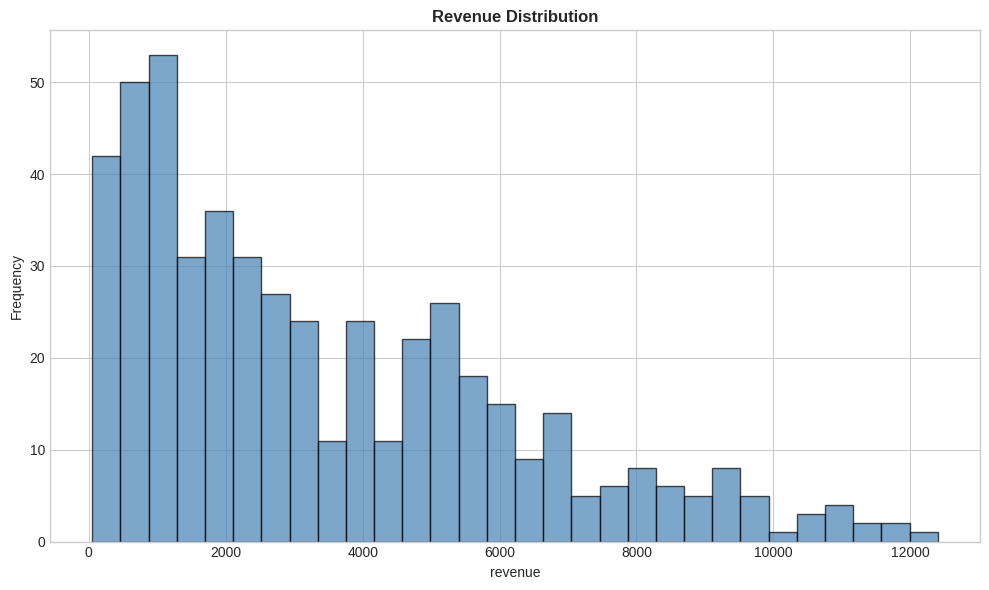


🤖 Analyst: The histogram of revenue distribution has been created successfully and displayed. If you need any further analysis or another visualization, feel free to ask!


👤 You: Show a bar chart of total revenue by region
📈 Creating bar: region vs revenue


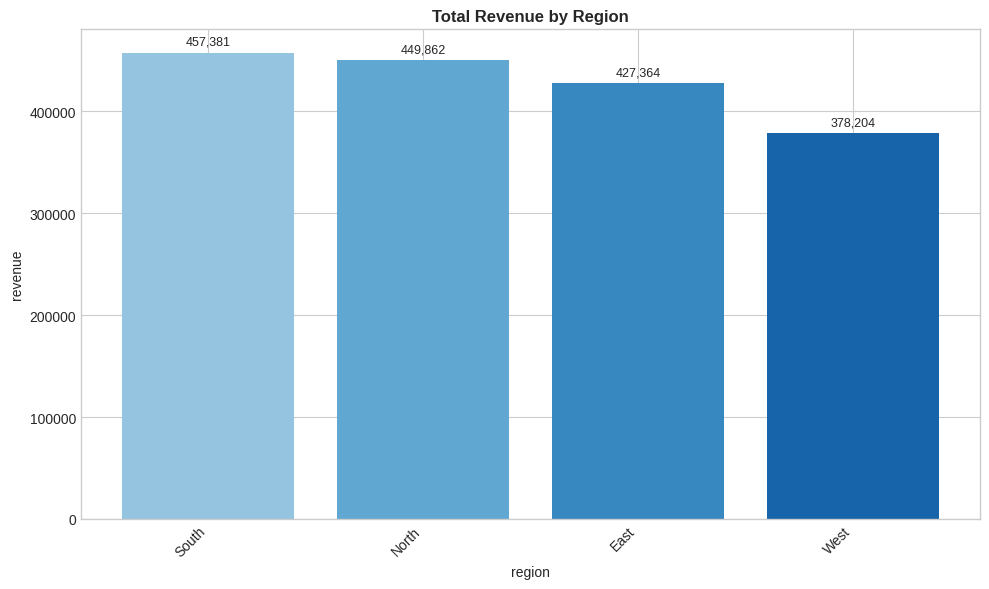


🤖 Analyst: The bar chart of total revenue by region has been created successfully and displayed. If you have any other requests or need further analysis, let me know!


👤 You: What's the correlation between quantity, unit_price, and revenue?
📈 Creating heatmap: quantity vs revenue


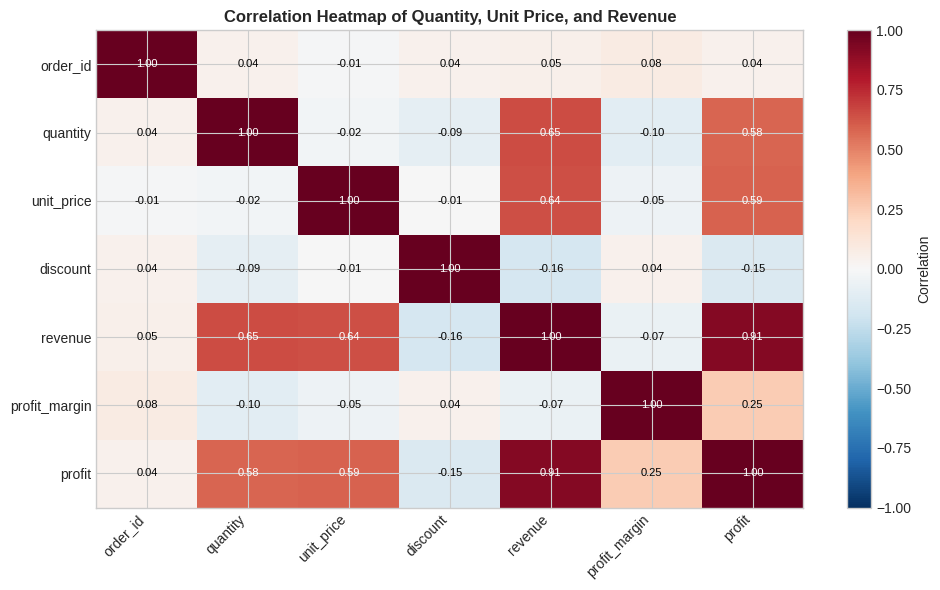


🤖 Analyst: The correlation heatmap of quantity, unit price, and revenue has been created successfully and displayed. If you have further questions or need additional analysis, feel free to ask!


👤 You: Is there a significant difference in revenue between customer types? Run ANOVA.
📊 Hypothesis test: anova on sales_data

🤖 Analyst: The One-Way ANOVA test was conducted to determine if there are significant differences in revenue across different customer types (Returning, VIP, and New). Here are the results:

### Group Statistics:
- **Returning Customers**:
  - Mean Revenue: $3223.56
  - Standard Deviation: $2719.59
  - Number of Customers: 247
- **VIP Customers**:
  - Mean Revenue: $3875.68
  - Standard Deviation: $2776.92
  - Number of Customers: 103
- **New Customers**:
  - Mean Revenue: $3449.30
  - Standard Deviation: $2796.29
  - Number of Customers: 150

### ANOVA Test Results:
- F-statistic: 2.0449
- p-value: 0.130482

### Conclusion:
- The p-value of 0.130 suggests that there 

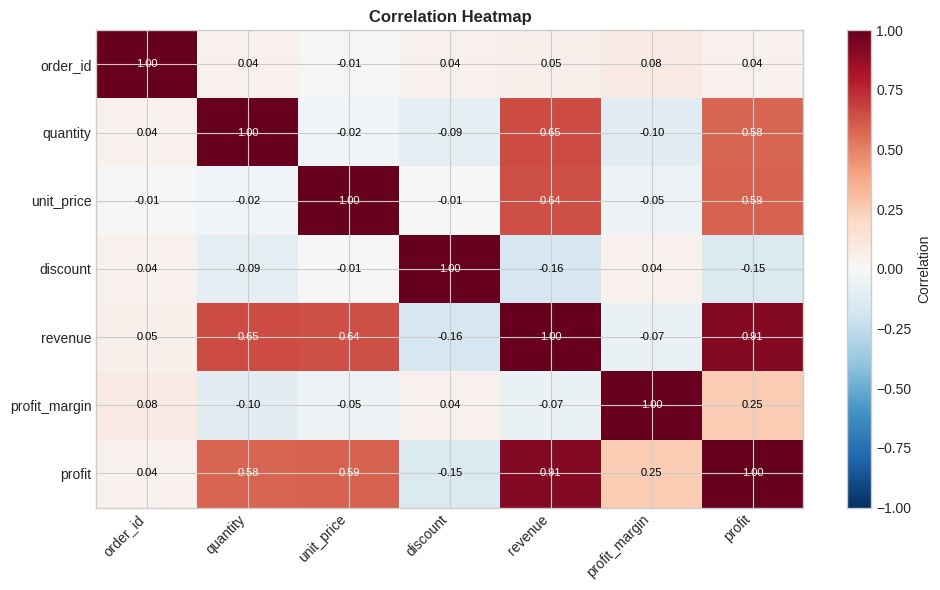


🤖 Analyst: The heatmap of correlations has been created successfully and displayed. If you need any further analysis or have additional questions, feel free to ask!


👤 You: Generate a summary report
📄 Generating report: sales_data

🤖 Analyst: ### Summary Report for Sales Dataset "sales_data"

**Report Generated At**: 2026-04-11 18:17:04

#### Overview
- **Total Rows**: 500
- **Total Columns**: 12
- **Numeric Columns**: 7
- **Categorical Columns**: 5
- **Memory Used**: 0.16 MB
- **Duplicate Rows**: 0
- **Complete Rows Percentage**: 100%

#### Data Quality
- **Total Missing Values**: 0
- **Missing Values Percentage**: 0.0%
- **Columns with Missing Values**: None

#### Numeric Insights
- **Order ID**:
  - Mean: 1249.5
  - Median: 1249.5
  - Standard Deviation: 144.48
  - Range: [1000.0, 1499.0]

- **Quantity**:
  - Mean: 4.94
  - Median: 5.0
  - Standard Deviation: 2.6
  - Range: [1.0, 9.0]

- **Unit Price**:
  - Mean: 775.91
  - Median: 792.92
  - Standard Deviation: 419.38
  - Range: 

In [2]:
data_loader_agent = Agent(
    name="data_loader",
    model=LiteLlm(model=MODEL),
    description="Loads CSV files, creates sample datasets (sales, customers, timeseries, survey)",
    instruction="""You load data into the analysis pipeline.

TOOLS:
- create_sample_dataset: Create test data. Types: 'sales', 'customers', 'timeseries', 'survey'
- load_csv: Load from file path or URL
- list_available_datasets: Show what's loaded

Always use clear dataset names like 'sales_data', 'customer_analysis'.""",
    tools=[load_csv, create_sample_dataset, list_available_datasets]
)

stats_agent = Agent(
    name="statistician",
    model=LiteLlm(model=MODEL),
    description="Statistical analysis: descriptive stats, correlations, hypothesis tests, outliers",
    instruction="""You perform statistical analysis.

TOOLS:
- describe_dataset: Full descriptive statistics
- correlation_analysis: Correlation matrix (pearson/spearman)
- hypothesis_test: Tests (normality, ttest, anova, chi2)
- outlier_detection: Find outliers (iqr/zscore)

Explain results in plain language alongside statistics.""",
    tools=[describe_dataset, correlation_analysis, hypothesis_test, outlier_detection]
)

viz_agent = Agent(
    name="visualizer",
    model=LiteLlm(model=MODEL),
    description="Creates charts: histogram, scatter, bar, line, box, heatmap, pie",
    instruction="""You create visualizations.

TOOLS:
- create_visualization: Charts (histogram, scatter, bar, line, box, heatmap, pie)
- create_distribution_report: 4-plot distribution analysis

GUIDE:
- Single variable distribution → histogram or box
- Two numeric variables → scatter
- Category comparison → bar
- Time trends → line
- Correlations overview → heatmap""",
    tools=[create_visualization, create_distribution_report]
)

transform_agent = Agent(
    name="transformer",
    model=LiteLlm(model=MODEL),
    description="Data transformation: filter, aggregate, calculate columns",
    instruction="""You transform data.

TOOLS:
- filter_data: Filter rows (e.g., condition='age > 30')
- aggregate_data: Group & aggregate (e.g., group_by='region', aggregations='revenue:sum,profit:mean')
- add_calculated_column: New columns (e.g., expression='revenue * 0.1')

Always create new dataset names - don't overwrite originals.""",
    tools=[filter_data, aggregate_data, add_calculated_column]
)

report_agent = Agent(
    name="reporter",
    model=LiteLlm(model=MODEL),
    description="Generates summary reports and tracks analysis history",
    instruction="""You create reports.

TOOLS:
- generate_summary_report: Comprehensive dataset summary
- get_analysis_history: View all analyses performed""",
    tools=[generate_summary_report, get_analysis_history]
)

print("✅ Specialist agents created!")

master_analyst = Agent(
    name="data_analyst",
    model=LiteLlm(model=MODEL),
    description="Master Data Analyst orchestrating end-to-end data analysis",
    instruction="""You are an expert Data Analyst with a team of specialists.

YOUR TEAM:
1. data_loader - Load/create datasets
2. statistician - Statistical analysis
3. visualizer - Charts and plots
4. transformer - Data transformations
5. reporter - Reports and summaries

WORKFLOW:
1. Load data → 2. Describe → 3. Visualize → 4. Analyze → 5. Transform if needed → 6. Report

Be helpful, explain insights clearly, suggest next steps.""",
    sub_agents=[data_loader_agent, stats_agent, viz_agent, transform_agent, report_agent]
)

print(f"✅ Master Analyst ready with {len(master_analyst.sub_agents)} specialists!")

session_service = InMemorySessionService()
APP_NAME = "data_pipeline"
USER_ID = "analyst"
SESSION_ID = "session_001"

async def init():
    return await session_service.create_session(
        app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID,
        state={"loaded_datasets": [], "active_dataset": None}
    )

session = await init()

runner = Runner(agent=master_analyst, app_name=APP_NAME, session_service=session_service)

async def analyze(query: str):
    print(f"\n{'='*70}\n👤 You: {query}\n{'='*70}")

    content = types.Content(role='user', parts=[types.Part(text=query)])
    response = ""

    try:
        async for event in runner.run_async(user_id=USER_ID, session_id=SESSION_ID, new_message=content):
            if event.is_final_response() and event.content and event.content.parts:
                response = event.content.parts[0].text
                break
    except Exception as e:
        response = f"Error: {str(e)}"

    print(f"\n🤖 Analyst: {response}\n{'='*70}\n")

print("✅ Ready! Use: await analyze('your question')")

print("="*70 + "\n  🚀 DATA ANALYSIS DEMO\n" + "="*70)

await analyze("Create a sales dataset for analysis")

await analyze("Describe the sales_data - what columns and statistics do we have?")

await analyze("Create a histogram of revenue")

await analyze("Show a bar chart of total revenue by region")

await analyze("What's the correlation between quantity, unit_price, and revenue?")

await analyze("Is there a significant difference in revenue between customer types? Run ANOVA.")

await analyze("Check for outliers in the revenue column")

await analyze("Create a heatmap of correlations")

await analyze("Generate a summary report")

print("""
╔════════════════════════════════════════════════════════════════════╗
║  🎯 INTERACTIVE DATA ANALYSIS                                       ║
╠════════════════════════════════════════════════════════════════════╣
║  Try these:                                                         ║
║                                                                     ║
║  await analyze("Create a customers dataset")                        ║
║  await analyze("Show scatter plot of age vs income")                ║
║  await analyze("Is income normally distributed?")                   ║
║  await analyze("Compare income between education levels")           ║
║  await analyze("Filter customers where age > 40")                   ║
║  await analyze("Calculate average lifetime_value by churn_risk")    ║
╚════════════════════════════════════════════════════════════════════╝
""")